# Market Regime Dynamics

## Objective

The objective of this notebook is to analyze the temporal behavior of the market regimes identified in the previous stage of the project. Rather than focusing on discovering new regimes, this notebook examines how the identified market states evolve over time, how frequently transitions occur between them, and how persistent each regime is throughout the historical period.

By studying the dynamics of market regimes, this analysis moves beyond static cluster interpretation to provide a deeper understanding of market behavior. The insights obtained in this notebook establish the foundation for future predictive models and decision-making frameworks that incorporate changes in market conditions.

## Notebook Roadmap

This notebook is organized into the following stages:

1. Prepare the market regime dataset.
2. Explore the historical evolution of market regimes.
3. Analyze regime transitions.
4. Measure regime persistence.
5. Summarize the dynamic behavior of the identified market regimes.

-----

## Environment Setup

Before beginning the market regime dynamics analysis, the required libraries, project configuration, and datasets are loaded. This initialization step ensures that all subsequent analyses are performed using a consistent and reproducible environment.

In [1]:
# ==========================================
# Import Libraries and Load Configuration
# ==========================================
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
import os 
import sys

# Absoulte Path To The Project Route
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

from config import *

In [2]:
# ==========================================
# Asset Names
# ==========================================
if len(ASSETS) != 1:
    raise ValueError(
        "This notebook is designed for single-asset analysis."
    )

asset_name = (
    ASSETS[0]
    .lower()
    .replace("-", "_")
)

In [3]:
# ==========================================
# Load Dataset
# ==========================================

market_regime_path = os.path.join(
    PROCESSED_DATA_PATH,
    f"{asset_name}_market_regime.csv"
)

market_regime_df = pd.read_csv(
    market_regime_path,
    parse_dates=["Date"],
    index_col = "Date"
)

In [4]:
# ==========================================
# Verify Dataset
# ==========================================
print("Dataset shape:", market_regime_df.shape)

market_regime_df.head()
market_regime_df.info()

Dataset shape: (3065, 5)
<class 'pandas.DataFrame'>
DatetimeIndex: 3065 entries, 2018-01-31 to 2026-06-22
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Returns        3065 non-null   float64
 1   Volatility     3065 non-null   float64
 2   Momentum       3065 non-null   float64
 3   Cluster_Id     3065 non-null   int64  
 4   Market_Regime  3065 non-null   str    
dtypes: float64(3), int64(1), str(1)
memory usage: 143.7 KB


-----

## Preparing the Market Regime Dataset

The market regime dataset exported in the previous notebook contains the complete output of the market regime detection stage. Before analyzing how market conditions evolve over time, it is important to verify that the dataset includes all the information required for the subsequent analyses.

This preparation step validates the structure of the dataset, confirms the presence of the financial features and market regime labels, and ensures that the observations are organized chronologically. Once these checks are completed, the dataset is ready to support the study of historical regime evolution, transition behavior, and regime persistence.

In [9]:
# ==========================================
# Verify Dataset Structure
# ==========================================
print("Date Range:")
print(f"Start:{market_regime_df.index.min()} ")
print(f"End: {market_regime_df.index.max()}")

print("\nNumber of Observations:")
print(len(market_regime_df))

print("\nMissing Values:")
print(market_regime_df.isnull().sum())

print("\nAvailable Columns:")
print(list(market_regime_df.columns))

print("\nMarket Regimes")
print(market_regime_df["Market_Regime"].value_counts().sort_index())

Date Range:
Start:2018-01-31 00:00:00 
End: 2026-06-22 00:00:00

Number of Observations:
3065

Missing Values:
Returns          0
Volatility       0
Momentum         0
Cluster_Id       0
Market_Regime    0
dtype: int64

Available Columns:
['Returns', 'Volatility', 'Momentum', 'Cluster_Id', 'Market_Regime']

Market Regimes
Market_Regime
High-Volatility Bearish         410
High-Volatility Transition      414
Low-Volatility Neutral         1683
Moderate-Volatility Bullish     558
Name: count, dtype: int64


-----

## Color Palette
Before going further let's stablish a color palette for future charts.

In [10]:
# ==========================================
# Market Regime Color Palette
# ==========================================

REGIME_COLORS = {
    "Moderate-Volatility Bullish": "#2ca02c",   # Green
    "Low-Volatility Neutral": "#1f77b4",        # Blue
    "High-Volatility Transition": "#ff7f0e",    # Orange
    "High-Volatility Bearish": "#d62728"        # Red
}

----

## Historical Evolution of Market Regimes

After identifying and characterizing the different market regimes, the next step is to examine how these regimes evolved throughout the historical period. Rather than analyzing each regime individually, this section focuses on their temporal distribution to understand when different market conditions occurred and how they changed over time.

Visualizing the sequence of market regimes provides valuable context for identifying prolonged periods of stability, bullish trends, bearish phases, and high-volatility transitions. This temporal perspective establishes the foundation for the transition and persistence analyses presented in the following sections.

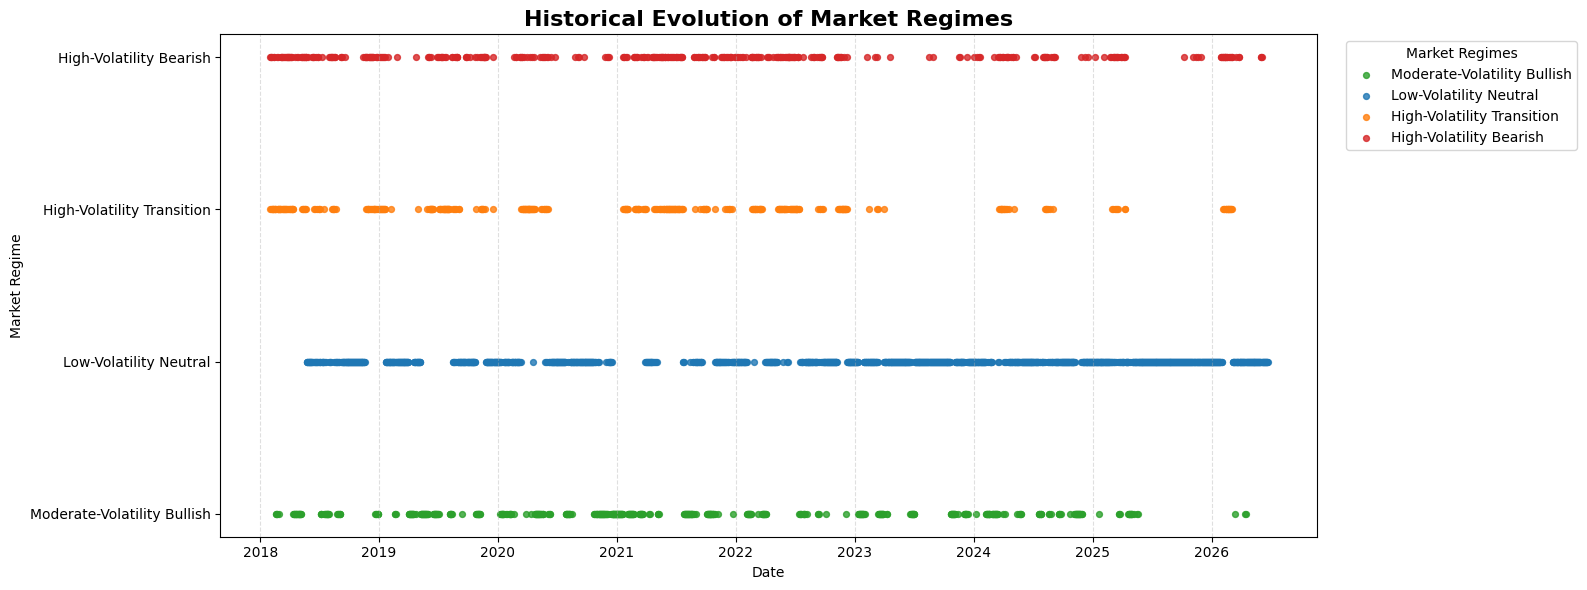

In [11]:
# ==========================================
# Historical Evolution of Market Regimes
# ==========================================

# Define the financial order of the regimes
regime_order = [
    "Moderate-Volatility Bullish",
    "Low-Volatility Neutral",
    "High-Volatility Transition",
    "High-Volatility Bearish"
]

# Create the figure
plt.figure(figsize=(16, 6))

# Plot each regime separately to preserve colors and legend
for regime in regime_order:
    regime_data = market_regime_df[
        market_regime_df["Market_Regime"] == regime
    ]

    plt.scatter(
        regime_data.index,
        [regime] * len(regime_data),
        color=REGIME_COLORS[regime],
        s=18,
        alpha=0.8,
        label=regime
    )

# Formatting
plt.title(
    "Historical Evolution of Market Regimes",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Market Regime")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.legend(
    title="Market Regimes",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()